# 3n-hp-DC Analysis

In [1]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [2]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/3n-hp-dc/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/3n-hp-dc/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/3n-hp-dc/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/3n-hp-dc/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/3n-hp-dc/combined/stats/"  # path to save results

## Distance Calcium and Ligand to pocket

In [3]:
# all three replica concatenated, trajectory centered on pocket residues
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'pocket_centered.xtc')

In [4]:
# this calculates the distance between pocket calcium atom and the Center of Mass of the binding pocket
cal = traj.select_atoms('resname CAL and resid 386')  # pocket calcium
pocket = traj.select_atoms('protein and (resid 347 or resid 349 or resid 354 or resid 365)') # pocket defining residues 

cal_pocket = []
R = np.zeros((cal.atoms.n_atoms, cal.atoms.n_atoms))  # just one atom/position per frame

for ts in traj.trajectory:
    pocket_com = pocket.center_of_geometry()  # calculates center of mass
    dist_arr = distances.distance_array(cal.positions,
                                       pocket_com,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    cal_pocket.append(dist_arr/10)  # convert from Angstr. to nm
cal_pocket_flat = np.concatenate([d.flatten() for d in cal_pocket])

In [5]:
# this calculates the distance between center of mass of mannose and the Center of Mass of the binding pocket
mannose = traj.select_atoms('resname LIG and (name C1 or name C2 or name C3 or name C4 or name C5 or name O5)')  # mannose ring atoms
pocket = traj.select_atoms('protein and (resid 347 or resid 349 or resid 354 or resid 365)')  # pocket defining residues 

lig_pocket = []
R = np.zeros((cal.atoms.n_atoms, cal.atoms.n_atoms))  # just one atom/position per frame

for ts in traj.trajectory:
    man_com = mannose.center_of_geometry() # 
    pocket_com = pocket.center_of_geometry()  # calculates center of mass
    dist_arr = distances.distance_array(man_com,
                                       pocket_com,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    lig_pocket.append(dist_arr/10)  # convert from Angstr. to nm

lig_pocket_flat = np.concatenate([d.flatten() for d in lig_pocket])

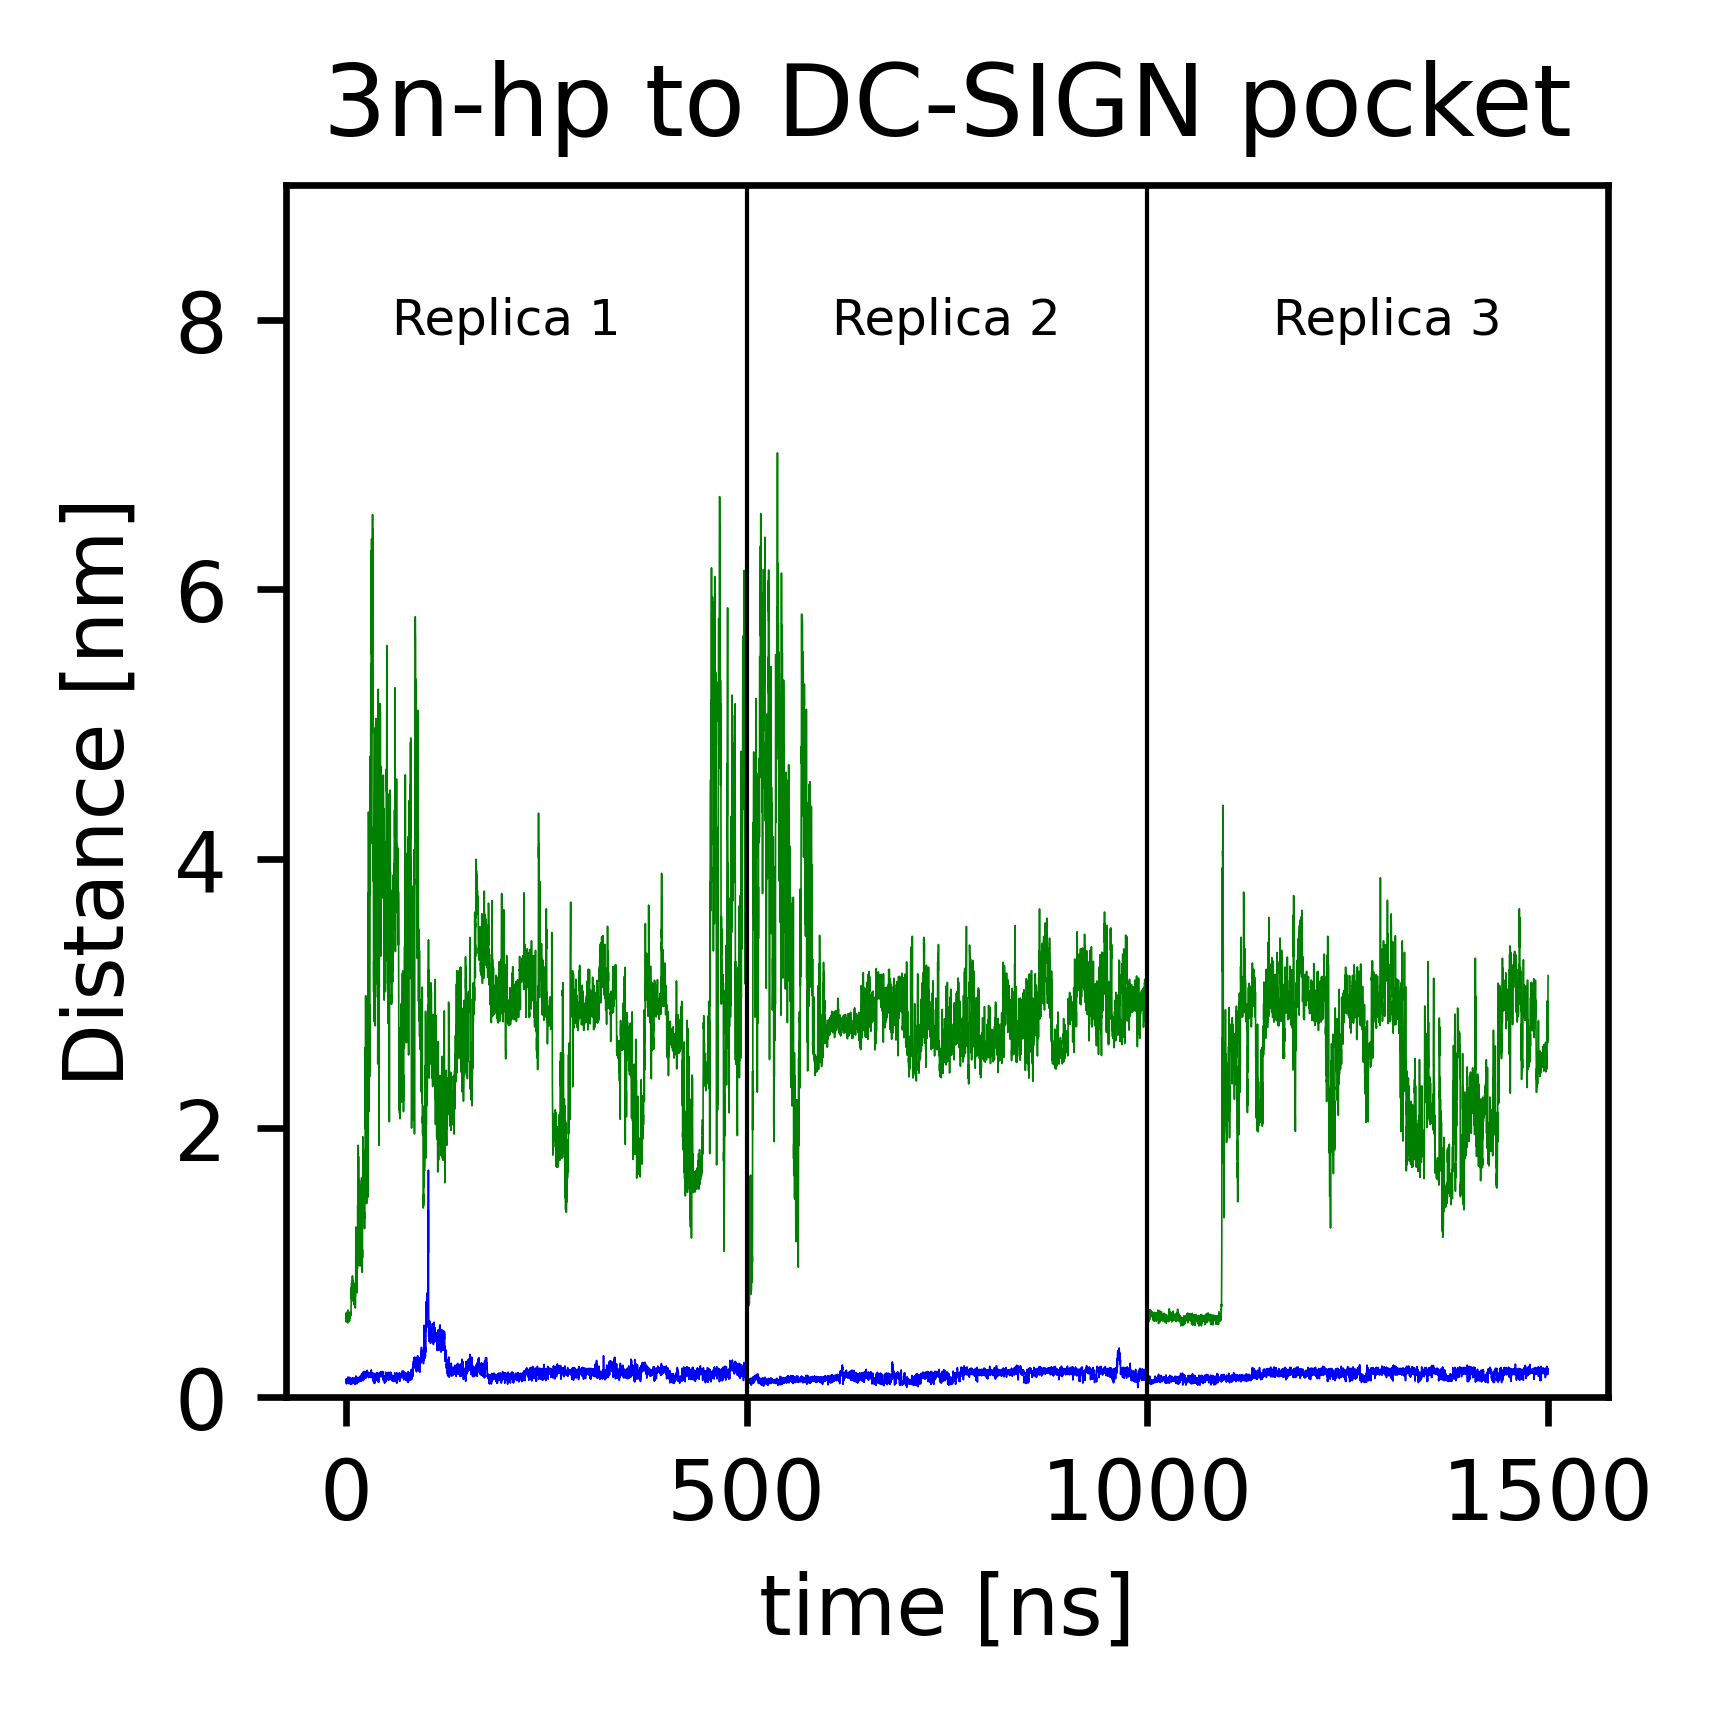

In [6]:
# plot Distances

cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(cal_pocket_flat, linewidth=0.2, c='#0000FF', alpha=1)  # RMSD Cal
ax.plot(lig_pocket_flat, linewidth=0.2, c='green', alpha=1)  # RMSD lig
plt.axvline(5000, color='#000000', linewidth=0.5)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=0.5)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('3n-hp to DC-SIGN pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('Distance [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/paper1_scripts_reproducability/distance_plots/3n-hp-dc.png")

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [27]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, len(rmsd_cal_center))
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, len(rmsd_cal_center))

In [28]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [29]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

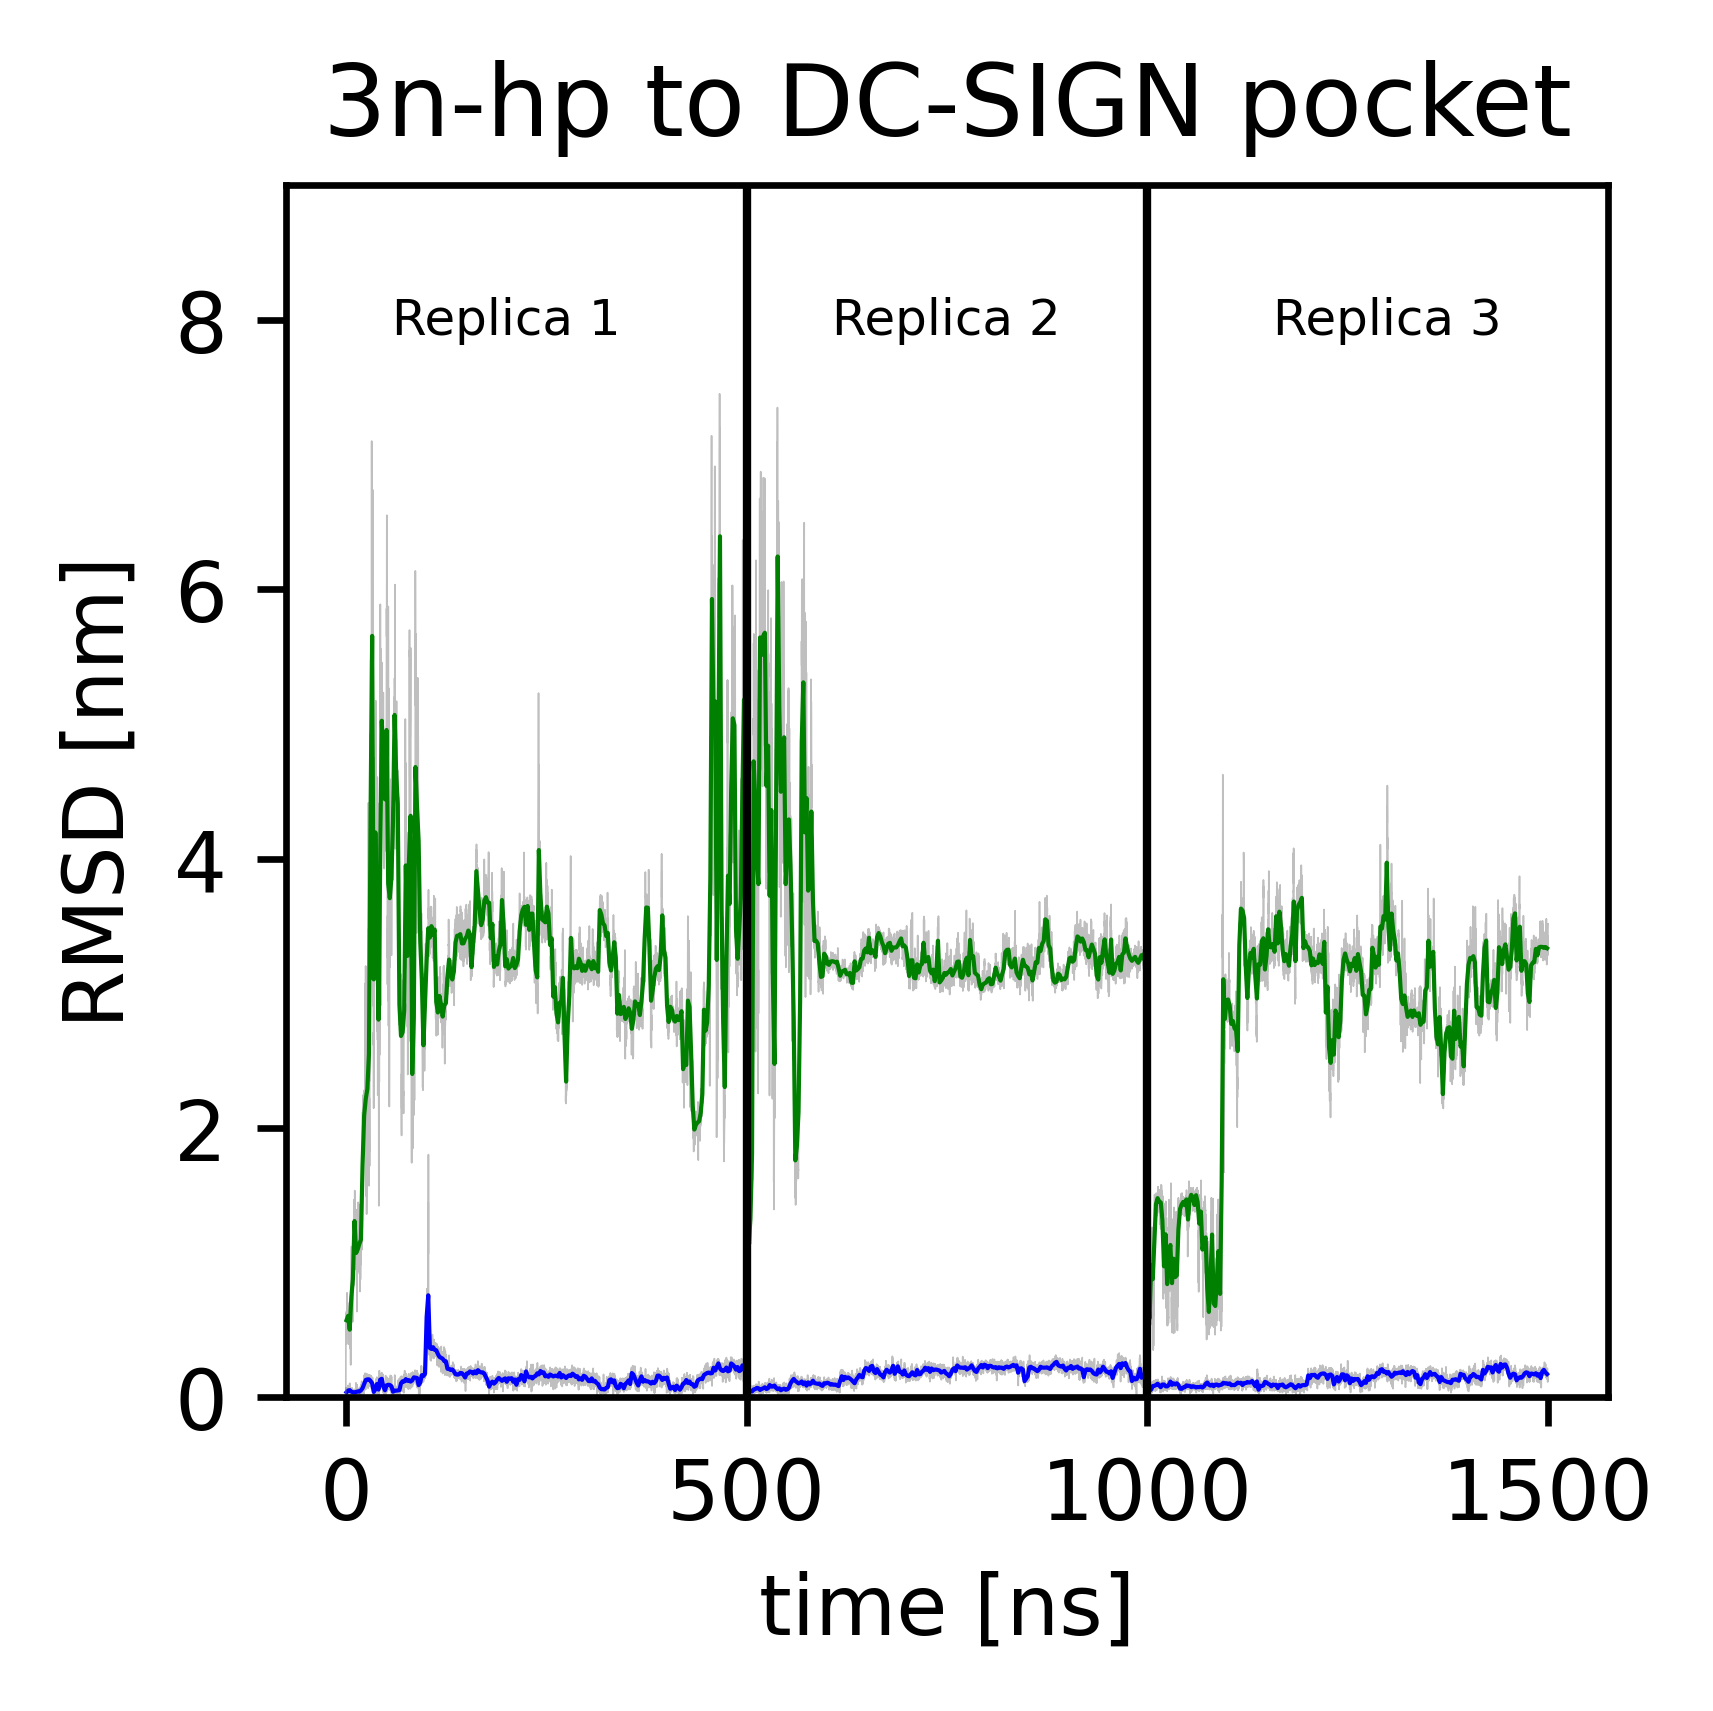

In [31]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('3n-hp to DC-SIGN pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/3n-hp-dc.png")

## different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu347, HO3 being close to Glu354, HO6 being far away from Glu358 and HO2 being far away from Glu347
- "state A" is defined by HO2 being close to Glu347, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu354
- "state B" is defined by HO2 being close to Glu354, HO4 being far from Glu347, HO6 being far from Glu358 and HO2 being far from Glu347
- "state C" is defined by HO6 being close to Glu358, HO3 being close to Glu354 and HO2 being far from Glu347 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [4]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 358
man = traj.select_atoms('resname LIG and name HO6')
prot = traj.select_atoms('protein and resid 358 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [5]:
# distance 2: HO2 to Glutamic Acid 347
man = traj.select_atoms('resname LIG and name HO2')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 3: HO3 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name HO3')
prot = traj.select_atoms('protein and resid 354 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 4: HO4 to Glutamic Acid 347 
man = traj.select_atoms('resname LIG and name HO4')
prot = traj.select_atoms('protein and resid 347 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 5: HO2 to Glutamic Acid 354
man = traj.select_atoms('resname LIG and name HO2')  
prot = traj.select_atoms('protein and resid 354 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [9]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save(f"{path_stats}distances_flat.npy", distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [10]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

93


In [11]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

819


In [12]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

0


In [13]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

0


In [14]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

141

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
However I will only do that if I get more than 100 frames for the state.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 101 frames, 10 ns, 10100 ps
- 2rep bound:  31 frames,  3 ns,  3100 ps
- 3rep bound: 921 frames, 92 ns, 92100 ps

  1053 frames in total -> 105300 ps

### crystal state & state B have less than 100 frames

### state A

In [16]:
ps = 100 # convert frames into pico seconds 
stateA_ps= [x*ps for x in stateA[:300]] 
print(*stateA_ps)

21300 21400 21500 21600 21700 21800 21900 22000 22100 22200 22300 22400 22500 22700 22800 22900 23100 23200 23300 23400 23500 23600 23700 23800 23900 24000 24100 24200 24300 24400 24500 24600 24700 24800 24900 25000 25100 25200 25400 25500 25600 25700 25800 25900 26000 26100 26200 26300 26400 26500 26600 26700 26800 26900 27000 27100 27200 27300 27500 27600 27700 27800 27900 28000 28100 28200 28400 28500 28600 28700 28800 28900 29000 29200 29400 29500 29600 29700 29800 29900 30000 30100 30200 30300 30400 30500 30600 30700 30800 30900 31000 31100 31200 31300 31400 31500 31600 31700 31800 31900 32000 32100 32200 32300 32400 32500 32600 32700 32800 32900 33000 33100 33200 33400 33500 33600 33700 33800 33900 34000 34100 34200 34400 34500 34700 34800 34900 35000 35100 35200 35300 35400 35500 35600 35700 35800 35900 36000 36100 36200 36300 36400 36500 36600 36700 36800 36900 37000 37100 37200 37300 37400 37500 37600 37700 37800 37900 38000 38100 38200 38300 38400 38500 38600 38700 38800 3890

In [17]:
# which frames are in replica 1?
print('frames in 1rep:')
for i in stateA_ps:
    if i <= 10100:
        print(i)

frames in 1rep:


In [18]:
# which frames are in replica 2?
print('frames in 2rep:')
for i in stateA_ps:
    if i > 10100 and i <= (10100+3100):
        print(i-10100)

frames in 2rep:


In [20]:
# which frames are in replica 3?
print('frames in 3rep:')
for i in stateA_ps[:300]:
    if i > (10100+3100):
        print(i-(10100+3100))

frames in 3rep:
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9500
9600
9700
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14300
14400
14500
14600
14700
14800
14900
15000
15200
15300
15400
15500
15600
15700
15800
16000
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18500
18600
18700
18800
18900
19000
19100
19200
19300
19400
19500
19600
19700
19800
19900
20000
20200
20300
20400
20500
20600
20700
20800
20900
21000
21200
21300
21500
21600
21700
21800
21900
22000
22100
22200
22300
22400
22500
22600
22700
22800
22900
23000
23100
23200
23300
23400
23500
23600
23700
23800
23900
24000
24100
24200
24300
24400
24500
24600
24700
24800
24900
25000
25100
25200
25300
25400
25500
25600
25700